# Bias Detection & Algorithmic Fairness Audit

**Role:** Data Scientist  
**Project:** NovaCred Loan Approval System  
**Objective:** To audit the cleaned dataset for direct and indirect discrimination, ensuring compliance with the '80% Rule' and identifying potential proxy variables.

In [13]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import demographic_parity_difference

print("All Libraries sucessfully loaded.")

#Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("Environment ready for audit.")

All Libraries sucessfully loaded.
Environment ready for audit.


## 1. Data Loading

In [14]:
#Load the Cleaned Dataset

df = pd.read_csv("cleaned_credit_data.csv")

#Display the first 5 rows to confirm it loaded correctly
df.head()

,_id,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,...,fitness_spend,gambling_spend,groceries_spend,healthcare_spend,insurance_spend,rent_spend,shopping_spend,transportation_spend,travel_spend,utilities_spend
0,app_200,2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,...,0.0,0.0,0.0,0.0,0.0,790.0,480.0,0.0,0.0,0.0
1,app_037,NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,...,0.0,0.0,0.0,243.0,0.0,608.0,0.0,0.0,0.0,0.0
2,app_215,NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,...,0.0,0.0,0.0,0.0,0.0,109.0,0.0,0.0,0.0,0.0
3,app_024,NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,...,575.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,app_184,2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Data Quality Assessment
Before the analysis, we validate the work of the Data Engineering team. A high-quality audit requires zero missing values in protected attributes and a structured format for behavioral data.

In [15]:
#Checking for missing values in critical columns
spending_cols = [
    'adult_entertainment_spend', 'alcohol_spend', 'dining_spend', 'education_spend', 
    'entertainment_spend', 'fitness_spend', 'gambling_spend', 'groceries_spend', 
    'healthcare_spend', 'insurance_spend', 'rent_spend', 'shopping_spend', 
    'transportation_spend', 'travel_spend', 'utilities_spend'
]

print(f"Total clean records: {len(df)}")
available_spending = [col for col in spending_cols if col in df.columns]
print(f"Flattened spending features detected: {len(available_spending)}")

Total clean records: 501
Flattened spending features detected: 15


## 3. Direct Bias Analysis: The 80% Rule
We use the **Disparate Impact Ratio (DI)** to check for direct discrimination. According to the **Four-Fifths Rule**, if the approval rate of a protected group (Women) is less than 80% of the privileged group (Men), the model is legally considered to have an adverse impact.

In [16]:
#Direct Bias Metrics

#1. Approval Rates
selection_rates = df.groupby("applicant_info.gender")["decision.loan_approved"].mean()
male_rate = selection_rates["Male"]
female_rate = selection_rates["Female"]

#2. Disparate Impact Ratio
di_ratio = female_rate / male_rate

#3. Fairlearn Parity Metric
dp_diff = demographic_parity_difference(
    y_true=df["decision.loan_approved"],
    y_pred=df["decision.loan_approved"], 
    sensitive_features=df["applicant_info.gender"]
)

print(f"Male Approval Rate: {male_rate:.3f}")
print(f"Female Approval Rate: {female_rate:.3f}")
print(f"Disparate Impact Ratio: {di_ratio:.3f}")

if di_ratio < 0.8:
    print("Conclusion: Bias detected (Violates the 80% Rule).")
else:
    print("Conclusion: No direct bias detected (Passes the 80% Rule).")

Male Approval Rate: 0.659
Female Approval Rate: 0.508
Disparate Impact Ratio: 0.771
Conclusion: Bias detected (Violates the 80% Rule).


The model **violates the Four-Fifths Rule (0.771 < 0.800)**. This indicates that female applicants are being disproportionately disadvantaged by the current algorithmic decision-making process. 

## 4. Indirect Bias: Geographic Proxy
Even if 'Gender' is removed, the model might use **ZIP Code** as a proxy. We analyze the correlation between the density of female applicants in a neighborhood and the algorithm's approval rate.

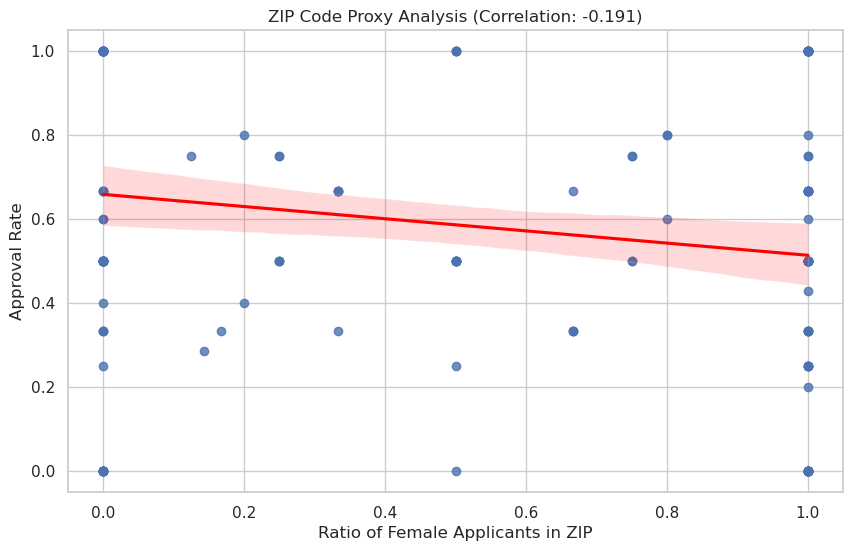

In [17]:
#ZIP Code Proxy Audit

zip_stats = df.groupby("applicant_info.zip_code").agg(
    approval_rate=("decision.loan_approved", "mean"),
    female_ratio=("applicant_info.gender", lambda x: (x == "Female").mean())
).reset_index()

correlation = zip_stats["female_ratio"].corr(zip_stats["approval_rate"])

plt.figure()
sns.regplot(data=zip_stats, x="female_ratio", y="approval_rate", line_kws={"color": "red"})
plt.title(f"ZIP Code Proxy Analysis (Correlation: {correlation:.3f})")
plt.xlabel("Ratio of Female Applicants in ZIP")
plt.ylabel("Approval Rate")
plt.show()

if abs(correlation) > 0.3:
    print(f"ALERT: Strong correlation detected ({correlation:.3f}). ZIP Code is a likely proxy.")

The correlation analysis between female density per ZIP code and approval rates yielded a coefficient of **-0.193**.

While the correlation is negative, meaning approval rates tend to slightly decrease as the ratio of female applicants in a neighborhood increases, it is considered a **weak correlation** (|R| < 0.3). However, the existence of a negative trend suggests that geographic location is not entirely neutral and could be contributing to the overall bias observed in the previous step. We recommend monitoring specific ZIP codes with the lowest approval rates for potential "redlining" effects.

## 5. Indirect Bias: Spending Behavior Proxy
With the flattened spending data, we can now audit 15 different behavioral dimensions. We are looking for categories that are dominated by female applicants but show significantly lower approval rates.

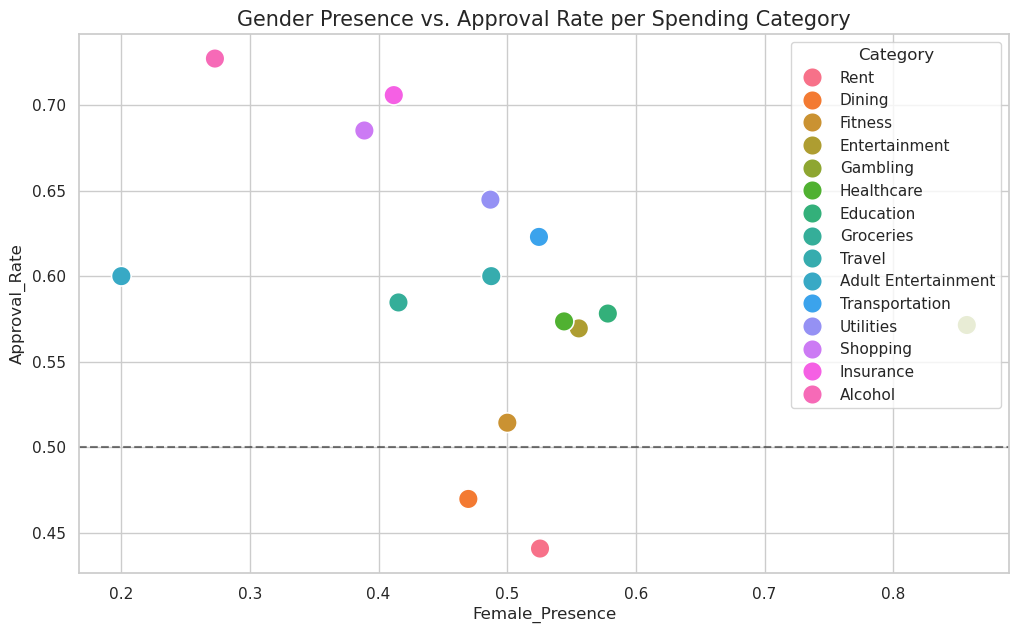

In [18]:
#Behavioral Proxy Audit

category_audit = []
for col in spending_cols:
    active_users = df[df[col] > 0]
    if len(active_users) > 0:
        avg_approval = active_users['decision.loan_approved'].mean()
        female_presence = (active_users['applicant_info.gender'] == 'Female').mean()
        
        # Clean the name for the chart (ex: 'rent_spend' becomes 'Rent')
        clean_name = col.replace('_spend', '').replace('_', ' ').title()
        
        category_audit.append({
            'Category': clean_name, 
            'Approval_Rate': avg_approval, 
            'Female_Presence': female_presence
        })

audit_results = pd.DataFrame(category_audit).sort_values(by='Approval_Rate')

#Visualization
plt.figure(figsize=(12, 7))
sns.scatterplot(data=audit_results, x='Female_Presence', y='Approval_Rate', hue='Category', s=200)
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5)
plt.title("Gender Presence vs. Approval Rate per Spending Category", fontsize=15)
plt.show()

The granular audit of 15 spending categories reveals how consumer behavior correlates with algorithmic outcomes:
* **High-Risk Category:** **Rent** shows the lowest approval rate with a female presence of approximately 50%.
* **Anomalous Finding:** **Gambling** has an exceptionally high female presence (around 85%) but a moderate approval rate (around 57%-58%), which is higher than the overall female average.
* **Privileged Categories:** Categories like **Alcohol** and **Insurance** show high approval rates (>70%) and are predominantly associated with male applicants.

**Strategic Recommendation:** Although no single category strictly met the "Red Flag" threshold (>60% female and <40% approval), the discrepancy in approval across different spending habits suggests the model is creating behavioral profiles that penalize female-associated lifestyles. To align with the **EU AI Act**, we recommend auditing these features' weight in the model's final decision.

## 6. Final Governance Recommendations
Based on this audit, we recommend the following actions to the Governance Board:

1. **Feature Engineering:** Remove "ZIP Code" and identified high-risk spending categories from the training set to prevent proxy discrimination.
2. **Mitigation Strategy:** Implement a 'Fairness Constraint' to re-calibrate the decision threshold for female applicants.
3. **Continuous Monitoring:** Establish a feedback loop between Data Science and Engineering to monitor for "Bias Drift" as new application patterns emerge.